<a href="https://colab.research.google.com/github/DSon24/-Data-Science-project-2/blob/main/Stroke_data_analysis_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (2).csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# Check for missing values
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
# Drop rows with missing values and recheck for missing values
df.dropna(inplace=True)
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
#Check for duplicate rows, missing number values in specific columns
df.duplicated().sum()
np.isnan(df['age']).sum()
np.isnan(df['bmi']).sum()
np.isnan(df['avg_glucose_level']).sum()


np.int64(0)

In [ ]:
#Is there a relationship between Residence type (Urban vs. Rural) and stroke risk?
residence_stroke = pd.crosstab(df['Residence_type'], df['stroke'])
residence_stroke

stroke,0,1
Residence_type,,
Rural,2319,100
Urban,2381,109


Text(0, 0.5, 'Number of people')

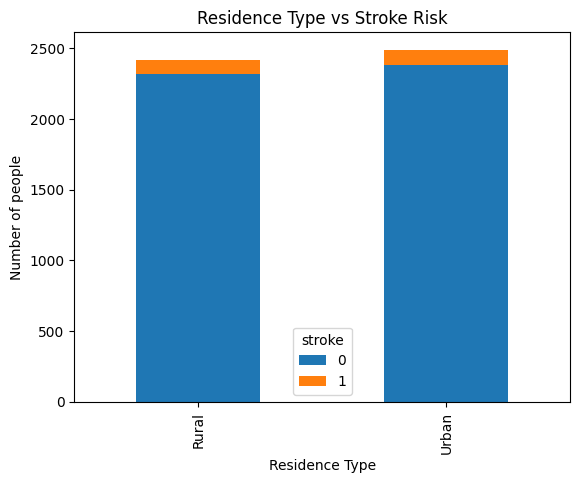

In [ ]:
#Plotting the relationship
residence_stroke.plot(kind='bar', stacked=True)
plt.title('Residence Type vs Stroke Risk')
plt.xlabel('Residence Type')
plt.ylabel('Number of people')

In [ ]:
#I use chi test to confirm the relationship one more time.
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(residence_stroke)
print(f"Chi-squared statistic = {chi2}, P-value: {p}")
# Because the p value is high (0.725 > 0.05), we fail to reject the null hypothesis so there is no relationship between Residence type and stroke risk.

Chi-squared statistic = 0.12382469623434333, P-value: 0.7249227580411615


Text(0, 0.5, 'Number of people')

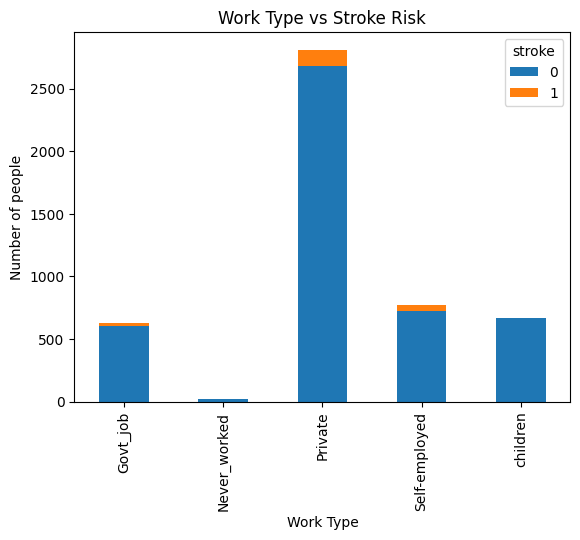

In [ ]:
#Does work type affect stroke risk directly, or is the effect explained by factors such as age, blood pressure, glucose level, or BMI?
#First I will visualize the relationship between work type and stroke risk.
work_stroke = pd.crosstab(df['work_type'], df['stroke'])
work_stroke.plot(kind='bar', stacked=True)
plt.title('Work Type vs Stroke Risk')
plt.xlabel('Work Type')
plt.ylabel('Number of people')


In [ ]:
#From the plot, it seems that work type may not effect stroke risk. It's just population imbalance. Confirming by calculating stroke rates for each work type.
#Calculate stroke rates for each work type
stroke_rates = df.groupby('work_type')['stroke'].mean()
print(stroke_rates)

work_type
Govt_job         0.044444
Never_worked     0.000000
Private          0.045180
Self-employed    0.068387
children         0.001490
Name: stroke, dtype: float64


In [ ]:
#g_job: 4.44%
#private: 4.51%
#self-employed: 6.84%
#Using chi square test to confirm if  work type has a significant effect on stroke risk.
chi2, p, dof, expected = chi2_contingency(work_stroke)
print(f"Chi-squared statistic = {chi2}, P-value: {p}")

Chi-squared statistic = 41.95353832836521, P-value: 1.7055668658884947e-08


In [ ]:
#P value is smaller than 0.05, so we reject the null hypothesis and conclude that work type has a significant effect on stroke risk.
#From the analysis, i see self-employed people have higher stroke risk compared to government job and private job people.
#This could be due to self-employed people is older than other two groups on average or other factors like higher blood pressure, glucose level, or BMI.
# Using logistic regression to control for these factors and see if work type still has a significant effect on stroke risk.
import statsmodels.formula.api as smf
model = smf.logit('stroke ~ work_type + age + bmi + avg_glucose_level + hypertension', data=df).fit()
print(model.summary())

         Current function value: 0.139756
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4909
Model:                          Logit   Df Residuals:                     4900
Method:                           MLE   Df Model:                            8
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.2061
Time:                        18:53:20   Log-Likelihood:                -686.06
converged:                      False   LL-Null:                       -864.19
Covariance Type:            nonrobust   LLR p-value:                 4.160e-72
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -8.1289      0.601    -13.526      0.000      -9.307      -6.951
work_type[T.Never

/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [ ]:
#This indicate that after controlling for age, bmi, avg_glucose_level, and hypertension, work type does not have a significant effect on stroke risk (p-values for work_type categories are greater than 0.05).

In [ ]:
p_values = model.pvalues
print(p_values)

Intercept                     1.105733e-41
work_type[T.Never_worked]     9.981014e-01
work_type[T.Private]          4.487311e-01
work_type[T.Self-employed]    2.888730e-01
work_type[T.children]         6.273489e-01
age                           1.468879e-33
bmi                           8.099113e-01
avg_glucose_level             1.229824e-04
hypertension                  1.374206e-03
dtype: float64


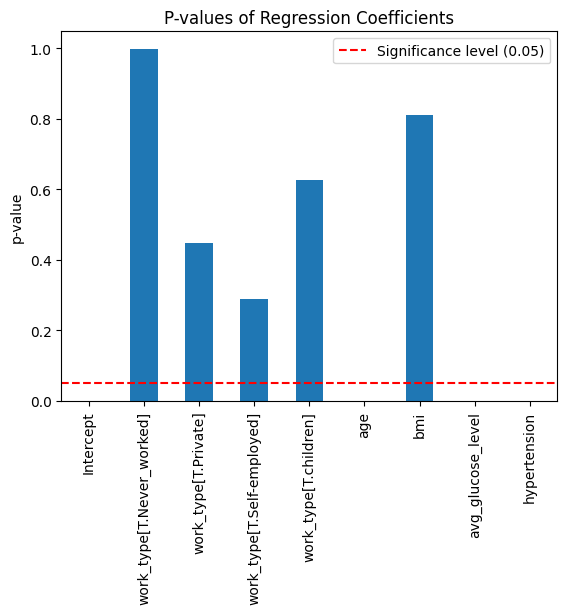

In [ ]:
#Visualizing the p-values of the regression coefficients
p_values.plot(kind='bar')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance level (0.05)')
plt.ylabel('p-value')
plt.title('P-values of Regression Coefficients')
plt.legend()
plt.show()

In [ ]:
#Is there a relationship between smoking status and stroke risk?
smoking_stroke = pd.crosstab(df['smoking_status'], df['stroke'])
smoking_stroke = smoking_stroke.drop(index='Unknown')  # Drop 'Unknown' category for clearer analysis
smoking_stroke

stroke,0,1
smoking_status,,
formerly smoked,780,57
never smoked,1768,84
smokes,698,39


In [ ]:
stroke_rates = df.groupby('smoking_status')['stroke'].mean()
stroke_rates = stroke_rates.drop(index='Unknown')
print(stroke_rates)

smoking_status
formerly smoked    0.068100
never smoked       0.045356
smokes             0.052917
Name: stroke, dtype: float64


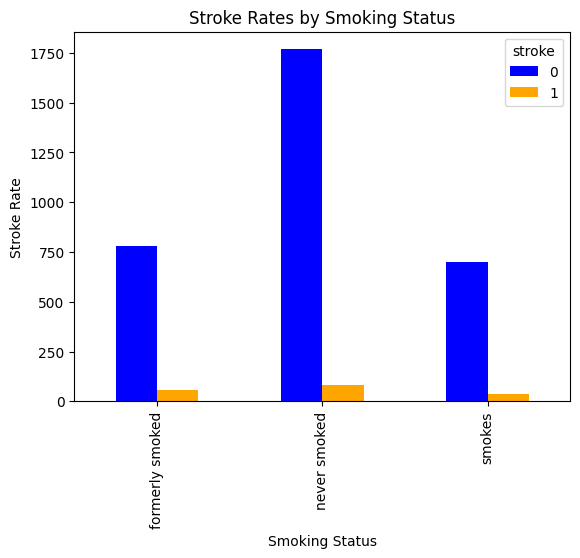

In [ ]:
#No sigificant difference in stroke rates among different smoking statuses.
smoking_stroke.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title('Stroke Rates by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Stroke Rate')
plt.show()

In [ ]:
chi2, p, dof, expected = chi2_contingency(smoking_stroke)
print(f"Chi-squared statistic = {chi2}, P-value: {p}")
# P value is high (0.5 = 0.05), so we  reject the null hypothesis and conclude that there is significant relationship between smoking status and stroke risk.

Chi-squared statistic = 5.993185308932129, P-value: 0.0499569994554728
